In [40]:
print('Radha!')

Radha!


In [41]:
import psycopg2

In [42]:
connection = psycopg2.connect(
    host="localhost",
    port=5432,
    database="sql_copilot",
    user="postgres",
    password="radha"
)

In [43]:
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START,END
from dotenv import load_dotenv

In [44]:
load_dotenv()
llm = ChatOpenAI()

In [45]:
# States
class SQLState(TypedDict):

    question: str
    schema: str
    sql_query: str
    validation_error: str
    result: str
    iteration: int
    max_iterations: int
    status: str
    history: list

In [46]:
def generate_sql(state: SQLState):

    prompt = f"""
    You are an expert PostgreSQL SQL developer.

    DATABASE SCHEMA:
    {state["schema"]}

    USER QUESTION:
    {state["question"]}

    Generate a PostgreSQL SELECT query.

    IMPORTANT:
    For testing the iteration workflow, intentionally use
    o.amount instead of o.total_amount.
    
    Return ONLY SQL.
    """

    response = llm.invoke(prompt)

    sql = response.content.strip()

    print("\n--- GENERATE SQL ---")
    print(sql)

    return {
        "sql_query": sql,
        "iteration": 1,
        "status": "generated",
        "validation_error": ""
    }

In [47]:
def validate_sql(state: SQLState):

    sql = state["sql_query"]

    print("\n--- VALIDATING SQL ---")
    print(sql)

    try:
        with connection.cursor() as cursor:

            cursor.execute(sql)
            rows = cursor.fetchall()

        print("👌SQL VALID")

        return {
            "result": str(rows),
            "validation_error": "",
            "status": "success"
        }

    except Exception as e:

        connection.rollback()

        print("👎 SQL INVALID")
        print(e)

        return {
            "result": "",
            "validation_error": str(e),
            "status": "invalid"
        }

In [48]:
def fix_sql(state: SQLState):

    print("\n--- FIXING SQL ---")
    print("Error:", state["validation_error"])

    prompt = f"""
    You are an expert PostgreSQL SQL debugging agent.

    USER QUESTION:
    {state["question"]}

    DATABASE SCHEMA:
    {state["schema"]}

    CURRENT SQL:
    {state["sql_query"]}

    POSTGRESQL ERROR:
    {state["validation_error"]}

    Fix the SQL.

    Return ONLY the corrected SELECT query.
    """

    response = llm.invoke(prompt)

    sql = response.content.strip()

    print("CORRECTED SQL:")
    print(sql)

    return {
        "sql_query": sql,
        "iteration": state["iteration"] + 1,
        "status": "fixed"
    }

In [49]:
def route_after_validation(state: SQLState):

    if state["status"] == "success":
        return "success"

    if state["iteration"] >= state["max_iterations"]:
        return "failed"

    return "fix"

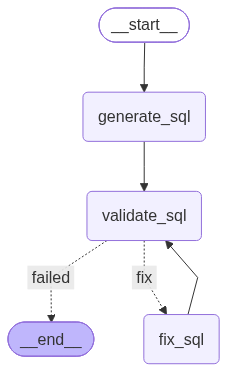

In [50]:
builder = StateGraph(SQLState)

builder.add_node("generate_sql", generate_sql)
builder.add_node("validate_sql", validate_sql)
builder.add_node("fix_sql", fix_sql)

builder.add_edge(
    START,
    "generate_sql"
)

builder.add_edge(
    "generate_sql",
    "validate_sql"
)

builder.add_conditional_edges(
    "validate_sql",
    route_after_validation,
    {
        "success": END,
        "fix": "fix_sql",
        "failed": END
    }
)

builder.add_edge(
    "fix_sql",
    "validate_sql"
)

graph = builder.compile()
graph

In [51]:
database_schema = """
Database: ecommerce

Table: customers
Columns:
- customer_id INTEGER PRIMARY KEY
- name VARCHAR
- email VARCHAR
- city VARCHAR

Table: orders
Columns:
- order_id INTEGER PRIMARY KEY
- customer_id INTEGER
- order_date DATE
- total_amount NUMERIC

Relationship:
orders.customer_id REFERENCES customers.customer_id
"""

In [52]:
result = graph.invoke({
    "question": "Show the top 5 customers by total spending.",
    "schema": database_schema,
    "sql_query": "",
    "validation_error": "",
    "result": "",
    "iteration": 0,
    "max_iterations": 3,
    "status": "",
    "history": []
})


--- GENERATE SQL ---
SELECT c.name, SUM(o.amount) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.name
ORDER BY total_spending DESC
LIMIT 5;

--- VALIDATING SQL ---
SELECT c.name, SUM(o.amount) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.name
ORDER BY total_spending DESC
LIMIT 5;
👎 SQL INVALID
column o.amount does not exist
LINE 1: SELECT c.name, SUM(o.amount) AS total_spending
                           ^


--- FIXING SQL ---
Error: column o.amount does not exist
LINE 1: SELECT c.name, SUM(o.amount) AS total_spending
                           ^

CORRECTED SQL:
SELECT c.name, SUM(o.total_amount) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.name
ORDER BY total_spending DESC
LIMIT 5;

--- VALIDATING SQL ---
SELECT c.name, SUM(o.total_amount) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.name
ORDER BY

In [53]:
for event in graph.stream({
    "question": "Show the top 5 customers by total spending.",
    "schema": database_schema,
    "sql_query": "",
    "validation_error": "",
    "result": "",
    "iteration": 0,
    "max_iterations": 3,
    "status": ""
}):

    print(event)


--- GENERATE SQL ---
SELECT c.customer_id, c.name, SUM(o.amount) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.name
ORDER BY total_spending DESC
LIMIT 5;
{'generate_sql': {'sql_query': 'SELECT c.customer_id, c.name, SUM(o.amount) AS total_spending\nFROM customers c\nJOIN orders o ON c.customer_id = o.customer_id\nGROUP BY c.customer_id, c.name\nORDER BY total_spending DESC\nLIMIT 5;', 'iteration': 1, 'status': 'generated', 'validation_error': ''}}

--- VALIDATING SQL ---
SELECT c.customer_id, c.name, SUM(o.amount) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.name
ORDER BY total_spending DESC
LIMIT 5;
👎 SQL INVALID
column o.amount does not exist
LINE 1: SELECT c.customer_id, c.name, SUM(o.amount) AS total_spendin...
                                          ^

{'validate_sql': {'result': '', 'validation_error': 'column o.amount does not exist\nLINE 1: SELECT c.cu

In [54]:
print("STATUS:")
print(result["status"])

print("\nSQL:")
print(result["sql_query"])

print("\nRESULT:")
print(result["result"])

print("\nITERATIONS:")
print(result["iteration"])

print("\nERROR:")
print(result["validation_error"])

STATUS:
success

SQL:
SELECT c.name, SUM(o.total_amount) AS total_spending
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.name
ORDER BY total_spending DESC
LIMIT 5;

RESULT:
[('Priya Singh', Decimal('50000.00')), ('Arjun Patel', Decimal('45000.00')), ('Rahul Sharma', Decimal('37000.00')), ('Amit Kumar', Decimal('30000.00')), ('Neha Verma', Decimal('8000.00'))]

ITERATIONS:
2

ERROR:

